In [19]:
import importlib
import numpy as np

import os
import matplotlib.pyplot as plt

os.environ["GRB_LICENSE_FILE"] = r"C:\Users\PC3\Desktop\gurobi.lic"
#os.environ["GRB_LICENSE_FILE"] = r"C:\Users\tomas\Desktop\gurobi.lic"

import gurobipy as gp
from gurobipy import GRB 


import uc_pipeline
import uc_experiment_builders
import uc_branch_sandwich_4b
import uc_master_relax_4b

importlib.reload(uc_pipeline)
importlib.reload(uc_experiment_builders)
importlib.reload(uc_branch_sandwich_4b)
importlib.reload(uc_master_relax_4b)


<module 'uc_master_relax_4b' from 'c:\\Users\\PC3\\Desktop\\Counterfactual-Explanations-for-optimization-problems\\Mixed\\UC-Experiments\\uc_master_relax_4b.py'>

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace
from typing import Optional, Callable, Dict, Tuple

import gurobipy as gp

from uc_branch_sandwich_4b import UCBranchAndSandwichWCE_4b

from uc_pipeline import (
    NetworkUCData, IndexMap,
    build_index_map_network_uc,
    build_cost_vector_network_uc,
    default_initial_conditions,
    solve_uc_with_cost_4b,
    make_curtailment_foil_4b,
    make_emissions_foil_4b,
)

def make_line_weights(DATA, b0, util=None, alpha=1.0, beta=1.0, gamma=0.5, eps_u=0.05):
    """
    w_ell ~ (x_proxy)^alpha * (b0)^beta * (1/(eps+util))^gamma
    then normalized to mean 1 and clipped.
    """
    import numpy as np

    b_susc = np.array([float(L.b) for L in DATA.lines], dtype=float)     # susceptance
    x_proxy = 1.0 / np.maximum(np.abs(b_susc), 1e-9)                     # reactance proxy

    x_med  = np.median(x_proxy)
    b0_med = np.median(b0)

    w = (x_proxy / max(x_med, 1e-9))**alpha * (b0 / max(b0_med, 1e-9))**beta

    if util is not None:
        w *= (1.0 / (eps_u + util))**gamma

    w = w / np.mean(w)
    w = np.clip(w, 0.1, 10.0)
    return w

In [21]:
import importlib
import uc_experiment_builders
importlib.reload(uc_experiment_builders)

from uc_experiment_builders import (
    load_network_uc_from_excel_fixed,
    make_scenario_data,
)
XLSX_PATH = r"C:\Users\PC3\Desktop\Counterfactual-Explanations-for-optimization-problems\Mixed\UC-Experiments\RedEjemploRiesgoConfiabilidad.xlsx"

#XLSX_PATH = r"C:\Users\tomas\Documents\GitHub\Counterfactual-Explanations-for-optimization-problems\Mixed\UC-Experiments\RedEjemploRiesgoConfiabilidad.xlsx"

base_data = load_network_uc_from_excel_fixed(
    xlsx_path=XLSX_PATH,
    wind_scenario=2,
    solar_scenario="Alto",
    curt_penalty=1000.0,
    allow_shifting=True,
    carbon_price=0.0,
    slack_bus=0,
    rep_params=None,
    emission_rates=None,
)

ARCHETYPE_SEED = 7
REN_SCALE = 2.0
DATA, types = make_scenario_data(base_data, archetype_seed=ARCHETYPE_SEED, ren_scale=REN_SCALE)

print("Scenario ready:", DATA.demand.shape, "#gens", len(DATA.gens), "#rens", len(DATA.rens), "#lines", len(DATA.lines))


Scenario ready: (14, 24) #gens 6 #rens 4 #lines 20


In [22]:
T  = int(DATA.T)
nB = int(DATA.nB)
nG = len(DATA.gens)
nR = len(DATA.rens)
nL = len(DATA.lines)

per_bus_neutrality = True
window_size = T  # usually T for WCE

idx = build_index_map_network_uc(nG=nG, nR=nR, nB=nB, nL=nL, T=T, major="t")

fuel_cost_vec     = np.array([g.fuel_cost for g in DATA.gens], dtype=float)
emission_rate_vec = np.array([g.emission_rate for g in DATA.gens], dtype=float)
no_load_cost_vec  = np.array([g.no_load_cost for g in DATA.gens], dtype=float)
su_cost_vec       = np.array([g.SU_cost for g in DATA.gens], dtype=float)
sd_cost_vec       = np.array([g.SD_cost for g in DATA.gens], dtype=float)
curt_cost_mat     = np.vstack([r.curt_cost for r in DATA.rens]) if nR > 0 else np.zeros((0, T), dtype=float)

cvec = build_cost_vector_network_uc(
    idx=idx,
    fuel_cost=fuel_cost_vec,
    emission_rate=emission_rate_vec,
    carbon_price=float(getattr(DATA, "carbon_price", 0.0)),
    no_load_cost=no_load_cost_vec,
    su_cost=su_cost_vec,
    sd_cost=sd_cost_vec,
    curt_cost=curt_cost_mat,
    pi_plus=DATA.pi_plus,
    pi_minus=DATA.pi_minus,
    voll=float(getattr(DATA, "voll", 20000.0)),  # <<< NEW REQUIRED
)

b0 = np.array([float(L.fmax) for L in DATA.lines], dtype=float)


In [23]:
def replace_line_limits(data: NetworkUCData, b_line: np.ndarray) -> NetworkUCData:
    b_line = np.asarray(b_line, dtype=float).reshape(-1)
    assert len(b_line) == len(data.lines)

    new_lines = []
    for ell, L in enumerate(data.lines):
        new_lines.append(replace(L, fmax=float(b_line[ell])))

    return replace(data, lines=new_lines)

In [24]:
class UCWeakWCEOracle:
    def __init__(
        self,
        data: NetworkUCData,
        cvec: np.ndarray,
        idx: IndexMap,
        window_size: int,
        per_bus_neutrality: bool,
        u_init, p_init, on_t, off_t,
        foil_extra_constr_fn: Optional[Callable[[gp.Model, Dict], None]] = None,
        output_flag: int = 0,
        time_limit: Optional[float] = None,
        cache_decimals: int = 3,
    ):
        self.data = data
        self.cvec = np.asarray(cvec, float)
        self.idx  = idx
        self.window_size = int(window_size)
        self.per_bus_neutrality = bool(per_bus_neutrality)
        self.u_init, self.p_init, self.on_t, self.off_t = u_init, p_init, on_t, off_t
        self.foil_extra_constr_fn = foil_extra_constr_fn
        self.output_flag = int(output_flag)
        self.time_limit = time_limit
        self.cache_decimals = int(cache_decimals)
        self.cache_plain = {}
        self.cache_foil  = {}

    def _key(self, b_line):
        return tuple(np.round(np.asarray(b_line, float), self.cache_decimals))

    def solve_plain(self, b_line):
        key = self._key(b_line)
        if key in self.cache_plain:
            return self.cache_plain[key]

        data_b = replace_line_limits(self.data, b_line)
        m, sol, z = solve_uc_with_cost_4b(
            data=data_b, idx=self.idx, cvec=self.cvec,
            window_size=self.window_size, per_bus_neutrality=self.per_bus_neutrality,
            u_init=self.u_init, p_init=self.p_init, on_time_init=self.on_t, off_time_init=self.off_t,
            extra_constr_fn=None,
            output_flag=self.output_flag,
            time_limit=self.time_limit,
            fmax_override=None,
        )
        out = (None, None, None) if sol is None else (float(sol["obj"]), np.array(z, float), sol)
        self.cache_plain[key] = out
        return out

    def solve_foil(self, b_line):
        key = self._key(b_line)
        if key in self.cache_foil:
            return self.cache_foil[key]

        data_b = replace_line_limits(self.data, b_line)
        m, sol, z = solve_uc_with_cost_4b(
            data=data_b, idx=self.idx, cvec=self.cvec,
            window_size=self.window_size, per_bus_neutrality=self.per_bus_neutrality,
            u_init=self.u_init, p_init=self.p_init, on_time_init=self.on_t, off_time_init=self.off_t,
            extra_constr_fn=self.foil_extra_constr_fn,
            output_flag=self.output_flag,
            time_limit=self.time_limit,
            fmax_override=None,
        )
        out = (None, None, None) if sol is None else (float(sol["obj"]), np.array(z, float), sol)
        self.cache_foil[key] = out
        return out


u_init, p_init, on_t, off_t = default_initial_conditions(DATA)

oracle = UCWeakWCEOracle(
    data=DATA, cvec=cvec, idx=idx,
    window_size=window_size,
    per_bus_neutrality=per_bus_neutrality,
    u_init=u_init, p_init=p_init, on_t=on_t, off_t=off_t,
    foil_extra_constr_fn=None,
    output_flag=0,
    time_limit=None,
    cache_decimals=3,
)


In [25]:
v0, z0, sol0 = oracle.solve_plain(b0)
assert sol0 is not None, "Factual solve failed."

e = np.array([float(g.emission_rate) for g in DATA.gens], dtype=float)
E_factual = float(np.sum(e[:,None] * sol0["p"]))
alpha = 0.20  # reduce emissions by 10%
foil_extra = make_emissions_foil_4b(DATA, alpha=alpha, E_factual=E_factual)

oracle.foil_extra_constr_fn = foil_extra
oracle.cache_foil.clear()

vF, zFoil, solFoil = oracle.solve_foil(b0)
print("Factual obj:", v0, "| Foil feasible@b0?", solFoil is not None)


Factual obj: 2527699.6787385247 | Foil feasible@b0? True


In [26]:
# utilization from factual flows
f_abs_max = np.max(np.abs(sol0["f"]), axis=1)   # (nL,)
util = f_abs_max / np.maximum(b0, 1e-9)

thr = 0.75
b_free_idx = [ell for ell in range(nL) if util[ell] >= thr]
if len(b_free_idx) == 0:
    # safe fallback: free top-3 utilized
    b_free_idx = list(np.argsort(-util)[:min(3, nL)])

bL = b0.copy()
bU = b0.copy()
for ell in b_free_idx:
    bL[ell] = b0[ell]
    bU[ell] = 5.0 * b0[ell]

# weights (keep simple if you want)
w = make_line_weights(DATA, b0, util=util, alpha=1.0, beta=1.0, gamma=0.5)

def make_curtailment_violation_fn(curt_0: float, curt_target: float):
    """Factory: returns a violation fn closed over the specific baseline values."""
    def curtailment_violation(m, var, idx):
        s = m.addVar(lb=0.0, name="curt_viol")
        total_curt = gp.quicksum(
            var["curt"][i, t]
            for i in range(idx.curt.shape[0])
            for t in range(idx.curt.shape[1])
        )
        m.addConstr(
            s >= (total_curt - curt_target) / curt_0,
            name="curt_viol_constr"
        )
        m.update()
        return s
    return curtailment_violation


In [27]:
# Run plain UC at b0 to get baseline curtailment
_, plain_result, _ = oracle.solve_plain(b0)

# Cell 8 — fix: define curtailment foil FIRST, then rebuild oracle

curt_0 = float(np.sum(plain_result[idx.curt]))
alpha = 0.20
curt_target = (1 - alpha) * curt_0

print(f"Baseline curtailment: {curt_0:.4f}")
print(f"Target (after {alpha*100:.0f}% reduction): {curt_target:.4f}")

# Define the hard foil constraint for curtailment
def foil_extra_curt(m, var):
    total_curt = gp.quicksum(
        var["curt"][i, t]
        for i in range(idx.curt.shape[0])
        for t in range(idx.curt.shape[1])
    )
    m.addConstr(total_curt <= curt_target, name="foil_curt")

# Rebuild oracle with curtailment foil — NOT the emissions foil from Cell 6
oracle = UCWeakWCEOracle(
    data=DATA, cvec=cvec, idx=idx,
    window_size=window_size,
    per_bus_neutrality=per_bus_neutrality,
    u_init=u_init, p_init=p_init, on_t=on_t, off_t=off_t,
    foil_extra_constr_fn=foil_extra_curt,   # <-- curtailment foil
    output_flag=0,
    time_limit=None,
    cache_decimals=3,
)

viol_fn = make_curtailment_violation_fn(curt_0=curt_0, curt_target=curt_target)


bs = UCBranchAndSandwichWCE_4b(
    oracle=oracle,
    data=DATA, idx=idx, cvec=cvec,
    foil_extra_constr_fn=foil_extra_curt,
    b0=b0,
    b_bounds=(bL, bU),
    b_free_idx=b_free_idx,
    eps_b=1.0,
    eps_obj=1e-3,
    eps_weak=1e-3,
    max_nodes=125,
    relax_cost_ub=None,
    master_time_limit=None,
    output_flag=0,
    verbose=True,
    w=w,
    foil_violation_expr_fn=viol_fn,
    lagrange_penalty=200.0,
)

res_bs = bs.run(
    window_size=window_size,
    per_bus_neutrality=per_bus_neutrality,
    u_init=u_init, p_init=p_init, on_t=on_t, off_t=off_t,
    compute_final_mip_lb=True,    # opt-in
    mip_lb_time_limit=900.0,      # 15 minutes
)

print(f"Certified: {res_bs['certified']}")
print(f"MIP LB used: {res_bs['mip_lb_used']}")
print(f"Gap: {res_bs['gap']:.4f}")


print("B&S:", res_bs)
assert res_bs.get("success") and res_bs.get("b_hat") is not None, "No incumbent found."
b_hat = np.array(res_bs["b_hat"], dtype=float)


Baseline curtailment: 2089.8919
Target (after 20% reduction): 1671.9135
  [INC] b_max: F=472.0049 v=1895637.740 v_D=1895637.740
  [INNER_UB] best_inner_ub=2527699.6787
[BS] node=0000 olb=16.7099 inner=[1551574.26,2527699.68] bestF=472.0049 gLB=16.7099 gap=96.5%
  [weak_ok] FAIL: v_D=2996839.229089 > v=2103776.002369 + eps
  [INC] node=0000: F=236.0025 v=1918721.915 v_D=1918721.915
  [INNER_UB] best_inner_ub=2527699.6787
[BS] node=0001 olb=16.7099 inner=[1551574.26,2527699.68] bestF=236.0025 gLB=85.0493 gap=64.0%
  [weak_ok] FAIL: v_D=2996839.229089 > v=2103776.002369 + eps
  [INC] node=0001: F=201.8327 v=1918721.915 v_D=1918721.915
  [INNER_UB] best_inner_ub=2179489.4847
[BS] node=0003 olb=16.7099 inner=[1593698.85,2527699.68] bestF=201.8327 gLB=19.4978 gap=90.3%
  [weak_ok] FAIL: v_D=2996839.229089 > v=2103776.002369 + eps
[BS] node=0005 olb=16.7099 inner=[1593698.85,2527699.68] bestF=201.8327 gLB=19.4978 gap=90.3%
  [weak_ok] FAIL: v_D=2996839.229089 > v=2103776.002369 + eps
[BS] nod

In [28]:

F_best = float(res_bs.get("F_opt", np.nan))
F_best = float(res_bs.get("F_opt", np.nan))

# Try multiple keys for the lower bound
LB = res_bs.get("global_LB", None)
if LB is None:
    LB = res_bs.get("LB", None)
LB = float(LB) if LB is not None else np.nan

gap_abs = (F_best - LB) if (np.isfinite(F_best) and np.isfinite(LB)) else np.nan

# Relative gap (%) w.r.t incumbent
if np.isfinite(F_best) and np.isfinite(LB) and abs(F_best) > 1e-12:
    gap_pct = 100.0 * max(0.0, (F_best - LB)) / abs(F_best)
    lb_over_f = LB / F_best
else:
    gap_pct = np.nan
    lb_over_f = np.nan

print("\n==================== B&S REPORT ====================")
print(f"Nodes processed:     {res_bs.get('nodes')}")
print(f"Best F (incumbent):  {F_best:.6f}")
print(f"Best LB:             {LB:.6f}")
print(f"Abs gap (F-LB):      {gap_abs:.6f}")
print(f"Gap % (F-LB)/|F|:    {gap_pct:.3f}%")
print(f"LB/F (tightness):    {lb_over_f:.6f}")
print("====================================================\n")

delta_abs = b_hat - b0
b_hat_pu = b_hat / np.maximum(b0, 1e-12)
delta_pu = delta_abs / np.maximum(b0, 1e-12)

rows = []
for ell in b_free_idx:
    if abs(delta_abs[ell]) > 1e-9:
        fr = int(DATA.lines[ell].fr)
        to = int(DATA.lines[ell].to)
        rows.append((
            ell, fr, to,
            float(b0[ell]),
            float(b_hat[ell]),
            float(delta_abs[ell]),
            float(b_hat_pu[ell]),
            float(delta_pu[ell]),
            float(util[ell]),
        ))

rows.sort(key=lambda r: -abs(r[7]))  # sort by |Δpu|

print("\n--- Changed line limits (per-unit, sorted by |Δpu|) ---")
if not rows:
    print("(No line limits changed.)")
else:
    print("ell  fr->to     b0(MW)     b_hat(MW)    Δ(MW)     b_hat(pu)   Δ(pu)     util")
    for ell, fr, to, b0v, bhv, dv, bhpu, dpu, uti in rows:
        print(f"{ell:3d}  {fr:2d}->{to:2d}  {b0v:9.3f}  {bhv:9.3f}  {dv:8.3f}  {bhpu:9.3f}  {dpu:+8.3f}  {uti:6.3f}")



==================== B&S REPORT ====================
Nodes processed:     125
Best F (incumbent):  42.254763
Best LB:             16.942500
Abs gap (F-LB):      25.312263
Gap % (F-LB)/|F|:    59.904%
LB/F (tightness):    0.400961


--- Changed line limits (per-unit, sorted by |Δpu|) ---
ell  fr->to     b0(MW)     b_hat(MW)    Δ(MW)     b_hat(pu)   Δ(pu)     util
  0   0-> 1     60.000    165.000   105.000      2.750    +1.750   1.000
  2   1-> 2     40.000     60.000    20.000      1.500    +0.500   1.000
  1   0-> 4     60.000     75.000    15.000      1.250    +0.250   0.759
  3   1-> 3     60.000     75.000    15.000      1.250    +0.250   0.796
  5   2-> 3     50.000     62.500    12.500      1.250    +0.250   0.824
  7   3-> 6     70.000     87.500    17.500      1.250    +0.250   0.916


In [29]:
# After getting b_hat
_, result_hat, _ = oracle.solve_plain(b_hat)
_, result_foil, _ = oracle.solve_foil(b_hat)

curt_hat = float(np.sum(result_hat[idx.curt]))
print(f"Baseline curtailment:  {curt_0:.4f}")
print(f"b_hat curtailment:     {curt_hat:.4f}")
print(f"Target:                {curt_target:.4f}")
print(f"Foil satisfied:        {curt_hat <= curt_target + 1e-3}")
print(f"v_plain at b_hat:      {result_hat[idx.p].sum():.4f}")  # adjust to your cost index
print(f"WCE condition (v_D <= v_plain): {res_bs['v_D'] <= res_bs['v_plain'] + 1e-3}")

Baseline curtailment:  2089.8919
b_hat curtailment:     1668.8045
Target:                1671.9135
Foil satisfied:        True
v_plain at b_hat:      2152.5699
WCE condition (v_D <= v_plain): True


In [30]:
import numpy as np

n_samples = 10_000
F_opt = res_bs["F_opt"]
violations = 0
better_found = False

rng = np.random.default_rng(42)
for _ in range(n_samples):
    b_sample = b0.copy()
    for ell in b_free_idx:
        b_sample[ell] = rng.uniform(bL[ell], bU[ell])
    
    ok, vp, vD = bs.weak_ok(b_sample)
    if ok:
        F_sample = bs.F(b_sample)
        if F_sample < F_opt - 1e-3:
            better_found = True
            print(f"COUNTEREXAMPLE: F={F_sample:.4f} < F_opt={F_opt:.4f}")
            print(f"  b_sample={b_sample[b_free_idx]}")
            break

if not better_found:
    print(f"No counterexample found in {n_samples} samples — solution looks optimal")

  [weak_ok] FAIL: v_D=2001773.925402 > v=2001765.367412 + eps
  [weak_ok] FAIL: v_D=2187849.887679 > v=2004213.906062 + eps
  [weak_ok] FAIL: v_D=1909117.679145 > v=1909109.121156 + eps
  [weak_ok] FAIL: v_D=2295817.666634 > v=2098270.226345 + eps
  [weak_ok] FAIL: v_D=2365573.849672 > v=2094073.032243 + eps
  [weak_ok] FAIL: v_D=1895646.297584 > v=1895637.739595 + eps
  [weak_ok] FAIL: v_D=2101754.451013 > v=2063637.987909 + eps
  [weak_ok] FAIL: v_D=2256664.380713 > v=2089257.555472 + eps
  [weak_ok] FAIL: v_D=2120720.830415 > v=2073685.873554 + eps
  [weak_ok] FAIL: v_D=2107916.958821 > v=2070831.718502 + eps
  [weak_ok] FAIL: v_D=2115363.587532 > v=2081807.963433 + eps
  [weak_ok] FAIL: v_D=2171833.233015 > v=2004107.762989 + eps
  [weak_ok] FAIL: v_D=1896154.213943 > v=1896145.655954 + eps
  [weak_ok] FAIL: v_D=2132033.569098 > v=2078497.511656 + eps
  [weak_ok] FAIL: v_D=1895646.297584 > v=1895637.739595 + eps
  [weak_ok] FAIL: v_D=2069027.042210 > v=2044632.803625 + eps
  [weak_

KeyboardInterrupt: 

In [ ]:
def make_foil_extra(curt_target_a):
    def foil_extra(m, var):
        total_curt = gp.quicksum(
            var["curt"][i, t]
            for i in range(idx.curt.shape[0])
            for t in range(idx.curt.shape[1])
        )
        m.addConstr(total_curt <= curt_target_a, name="foil_curt")
    return foil_extra

results = {}
for alpha in [0.10, 0.20, 0.30, 0.40]:
    curt_target_a  = (1 - alpha) * curt_0
    foil_extra_a   = make_foil_extra(curt_target_a)
    viol_fn        = make_curtailment_violation_fn(curt_0, curt_target_a)

    # Rebuild oracle with the correct foil for this alpha
    oracle_a = UCWeakWCEOracle(
        data=DATA, cvec=cvec, idx=idx,
        window_size=window_size,
        per_bus_neutrality=per_bus_neutrality,
        u_init=u_init, p_init=p_init, on_t=on_t, off_t=off_t,
        foil_extra_constr_fn=foil_extra_a,   # <-- alpha-specific foil
        output_flag=0,
        time_limit=None,
        cache_decimals=3,
    )

    bs_a = UCBranchAndSandwichWCE_4b(
        oracle=oracle_a,                     # <-- use the new oracle
        data=DATA, idx=idx, cvec=cvec,
        foil_extra_constr_fn=foil_extra_a,
        b0=b0,
        b_bounds=(bL, bU),
        b_free_idx=b_free_idx,
        eps_b=1.0,
        eps_obj=1e-3,
        eps_weak=1e-3,
        max_nodes=15000,
        relax_cost_ub=None,
        master_time_limit=None,
        output_flag=0,
        verbose=False,
        w=w,
        foil_violation_expr_fn=viol_fn,
        lagrange_penalty=200.0,
    )

    res_a = bs_a.run(
        window_size=window_size,
        per_bus_neutrality=per_bus_neutrality,
        u_init=u_init, p_init=p_init, on_t=on_t, off_t=off_t,
    )
    results[alpha] = res_a["F_opt"]
    print(f"alpha={alpha:.0%}  F_opt={res_a['F_opt']:.4f}  "
          f"gap={res_a['gap']:.4f}  nodes={res_a['nodes']}")

F_vals = [results[a] for a in sorted(results)]
assert all(F_vals[i] <= F_vals[i+1] + 1e-3 for i in range(len(F_vals)-1)), \
    "Monotonicity violated — solution is wrong somewhere"
print("Monotonicity check passed")

  [DEBUG] lag_olb=2.699829 best_F=472.004928 eps=0.001 would_discard=False
  [DEBUG] lag_olb=2.699829 best_F=6.814174 eps=0.001 would_discard=False
  [DEBUG] lag_olb=71.039274 best_F=6.814174 eps=0.001 would_discard=True
  [DEBUG] lag_olb=2.699829 best_F=6.814174 eps=0.001 would_discard=False
  [DEBUG] lag_olb=13.628347 best_F=6.814174 eps=0.001 would_discard=True
  [DEBUG] lag_olb=2.699829 best_F=6.814174 eps=0.001 would_discard=False
  [DEBUG] lag_olb=61.199169 best_F=6.814174 eps=0.001 would_discard=True
  [DEBUG] lag_olb=2.699829 best_F=6.814174 eps=0.001 would_discard=False
  [DEBUG] lag_olb=47.950295 best_F=6.814174 eps=0.001 would_discard=True
  [DEBUG] lag_olb=2.699829 best_F=6.814174 eps=0.001 would_discard=False
  [DEBUG] lag_olb=32.686919 best_F=6.814174 eps=0.001 would_discard=True
  [DEBUG] lag_olb=2.699829 best_F=6.814174 eps=0.001 would_discard=False
  [DEBUG] lag_olb=22.965384 best_F=6.814174 eps=0.001 would_discard=True
  [DEBUG] lag_olb=2.699829 best_F=6.814174 eps=0.

In [ ]:
_, plain_result, _ = oracle.solve_plain(b0)
curt_0 = float(np.sum(plain_result[idx.curt]))

for alpha in [0.05, 0.10, 0.20, 0.30, 0.40]:
    curt_target_a = (1 - alpha) * curt_0
    print(f"alpha={alpha:.0%}  curt_target={curt_target_a:.2f}  "
          f"curt_0={curt_0:.2f}  already_satisfied={curt_0 <= curt_target_a + 1e-3}")

alpha=5%  curt_target=1985.40  curt_0=2089.89  already_satisfied=False
alpha=10%  curt_target=1880.90  curt_0=2089.89  already_satisfied=False
alpha=20%  curt_target=1671.91  curt_0=2089.89  already_satisfied=False
alpha=30%  curt_target=1462.92  curt_0=2089.89  already_satisfied=False
alpha=40%  curt_target=1253.94  curt_0=2089.89  already_satisfied=False


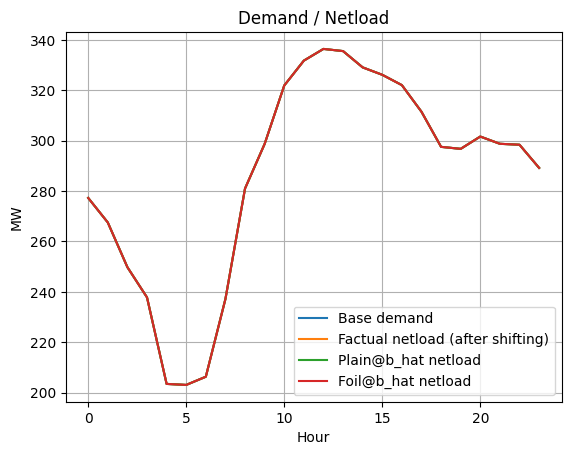

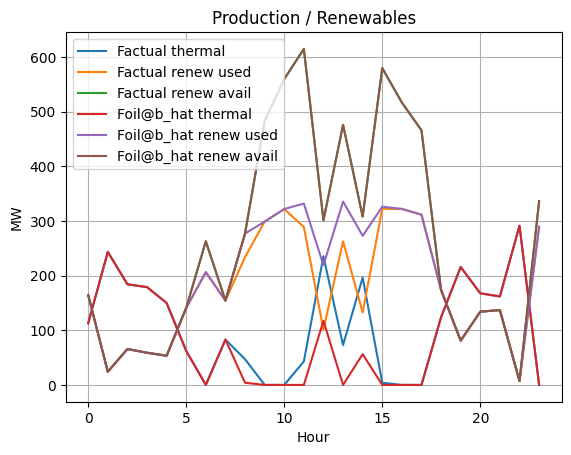

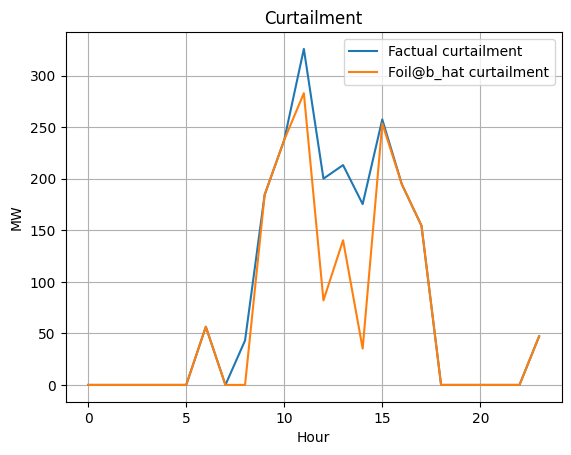

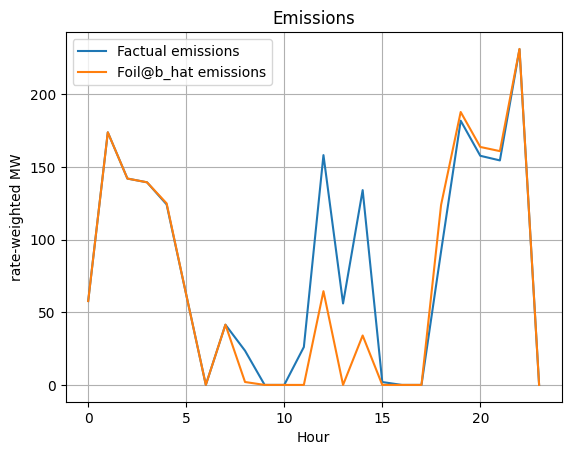

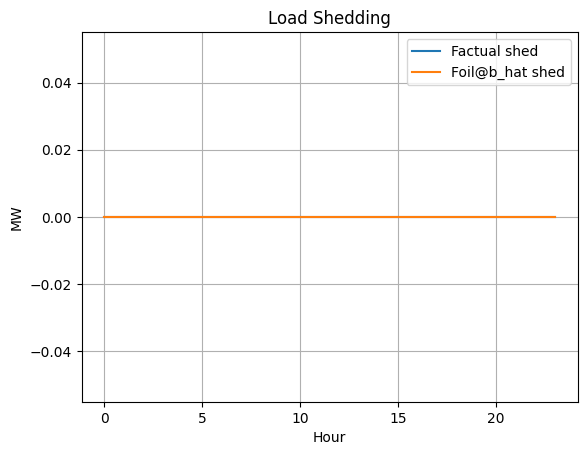

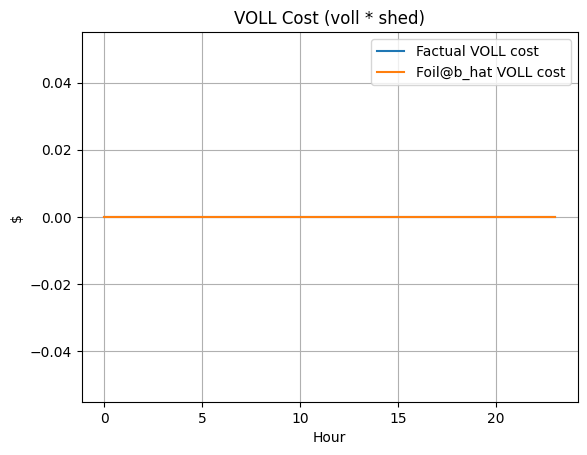

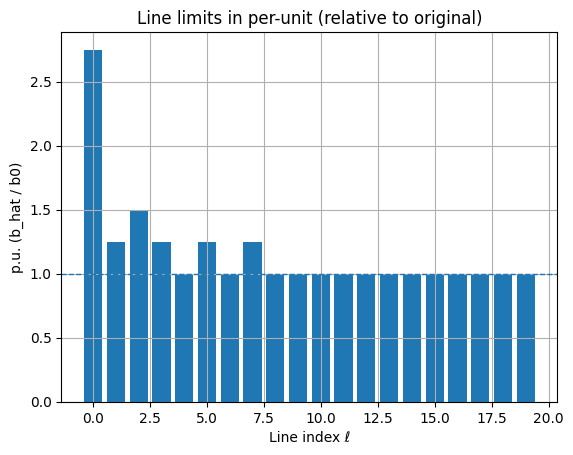

In [31]:
# evaluate plain + foil at b_hat
v_plain, z_plain, sol_plain = oracle.solve_plain(b_hat)
v_foil,  z_foil,  sol_foil  = oracle.solve_foil(b_hat)

assert sol_plain is not None, "Plain solve at b_hat failed."
assert sol_foil  is not None, "Foil solve at b_hat failed (unexpected)."

t = np.arange(T)
demand_total = DATA.demand.sum(axis=0)

def totals(sol):
    p_th = sol["p"].sum(axis=0)
    # renewables
    if len(DATA.rens) > 0:
        avail = np.vstack([r.avail for r in DATA.rens])
        curt  = sol["curt"]
        ren_used = (avail - curt).sum(axis=0)
        ren_av  = avail.sum(axis=0)
        curt_tot = curt.sum(axis=0)
    else:
        ren_used = np.zeros(T); ren_av = np.zeros(T); curt_tot = np.zeros(T)

    # emissions
    e = np.array([float(g.emission_rate) for g in DATA.gens], dtype=float)
    emis = (e[:,None] * sol["p"]).sum(axis=0)

    # shedding + VOLL
    shed = sol["shed"].sum(axis=0) if "shed" in sol else np.zeros(T)
    voll = float(getattr(DATA, "voll", 20000.0))
    voll_cost = voll * shed

    # netload if shifting exists
    if "splus" in sol and "sminus" in sol:
        netload_total = (DATA.demand + sol["splus"] - sol["sminus"]).sum(axis=0)
    else:
        netload_total = demand_total.copy()

    return dict(
        thermal=p_th,
        ren_used=ren_used,
        ren_avail=ren_av,
        curt=curt_tot,
        emissions=emis,
        shed=shed,
        voll_cost=voll_cost,
        netload=netload_total,
    )

TS_F = totals(sol0)        # factual @ b0
TS_P = totals(sol_plain)   # plain @ b_hat
TS_D = totals(sol_foil)    # foil  @ b_hat

# 1) Demand vs netload (shifted)
plt.figure()
plt.plot(t, demand_total, label="Base demand")
plt.plot(t, TS_F["netload"], label="Factual netload (after shifting)")
plt.plot(t, TS_P["netload"], label="Plain@b_hat netload")
plt.plot(t, TS_D["netload"], label="Foil@b_hat netload")
plt.xlabel("Hour"); plt.ylabel("MW"); plt.title("Demand / Netload")
plt.grid(True); plt.legend(); plt.show()

# 2) Supply stack (thermal + renewable used + avail)
plt.figure()
plt.plot(t, TS_F["thermal"], label="Factual thermal")
plt.plot(t, TS_F["ren_used"], label="Factual renew used")
plt.plot(t, TS_F["ren_avail"], label="Factual renew avail")
plt.plot(t, TS_D["thermal"], label="Foil@b_hat thermal")
plt.plot(t, TS_D["ren_used"], label="Foil@b_hat renew used")
plt.plot(t, TS_D["ren_avail"], label="Foil@b_hat renew avail")
plt.xlabel("Hour"); plt.ylabel("MW"); plt.title("Production / Renewables")
plt.grid(True); plt.legend(); plt.show()

# 3) Curtailment
plt.figure()
plt.plot(t, TS_F["curt"], label="Factual curtailment")
plt.plot(t, TS_D["curt"], label="Foil@b_hat curtailment")
plt.xlabel("Hour"); plt.ylabel("MW"); plt.title("Curtailment")
plt.grid(True); plt.legend(); plt.show()

# 4) Emissions
plt.figure()
plt.plot(t, TS_F["emissions"], label="Factual emissions")
plt.plot(t, TS_D["emissions"], label="Foil@b_hat emissions")
plt.xlabel("Hour"); plt.ylabel("rate-weighted MW"); plt.title("Emissions")
plt.grid(True); plt.legend(); plt.show()

# 5) Load shedding + VOLL cost
plt.figure()
plt.plot(t, TS_F["shed"], label="Factual shed")
plt.plot(t, TS_D["shed"], label="Foil@b_hat shed")
plt.xlabel("Hour"); plt.ylabel("MW"); plt.title("Load Shedding")
plt.grid(True); plt.legend(); plt.show()

plt.figure()
plt.plot(t, TS_F["voll_cost"], label="Factual VOLL cost")
plt.plot(t, TS_D["voll_cost"], label="Foil@b_hat VOLL cost")
plt.xlabel("Hour"); plt.ylabel("$"); plt.title("VOLL Cost (voll * shed)")
plt.grid(True); plt.legend(); plt.show()

# (3) Line capacities in per-unit: b_hat / b0
b_hat_pu = b_hat / np.maximum(b0, 1e-12)

x = np.arange(len(b0))
plt.figure()
plt.bar(x, b_hat_pu)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.xlabel("Line index ℓ"); plt.ylabel("p.u. (b_hat / b0)")
plt.title("Line limits in per-unit (relative to original)")
plt.grid(True); plt.show()
